In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import pandas as pd

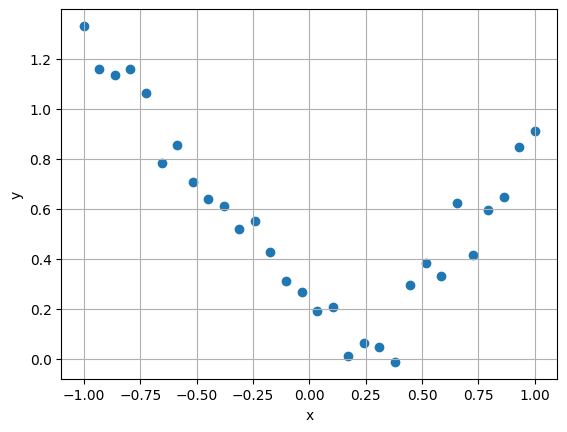

In [45]:
def true_function(x, noise_std=0.3):
    noise = noise_std * np.random.randn(len(x))
    return abs(x-0.2) + noise
n_samples = 30

# Data
np.random.seed(0)
X = np.linspace(-1, 1, n_samples)
y_true = true_function(X, noise_std=0.075)
X_test = np.linspace(-1.5, 1.5, 100)
y_true_test = true_function(X_test, noise_std=0)
plt.figure()
plt.scatter(X, y_true)
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.81779e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


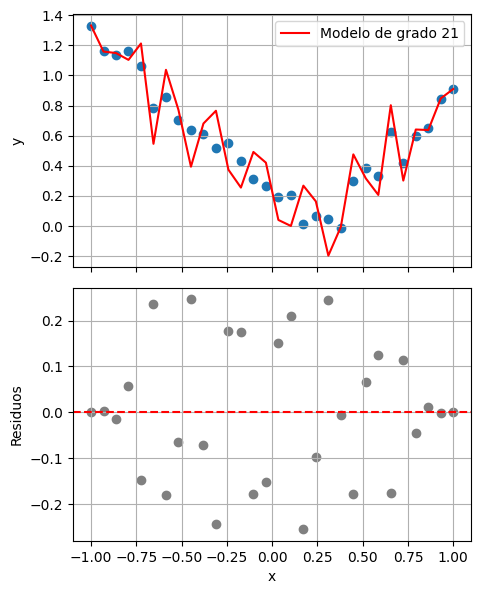

In [46]:
degree = 21

model = make_pipeline(
    PolynomialFeatures(degree, include_bias=False),
    Ridge(alpha=0)
)
model.fit(X.reshape(-1, 1), y_true)
y_pred = model.predict(X.reshape(-1, 1))

# Compute residuals
residuals = y_true - y_pred

# Plot with 2 subplots
fig, axs = plt.subplots(2, 1, figsize=(5, 6), sharex=True)

# Top: prediction vs true function
axs[0].scatter(X, y_true)
axs[0].plot(X, y_pred, c='r', label=f'Modelo de grado {degree}')
axs[0].legend(loc='best')
axs[0].grid(True)
axs[0].set_ylabel("y")

# Bottom: residuals
axs[1].scatter(X, residuals, color='gray')
axs[1].axhline(0, color='red', linestyle='--')
axs[1].set_xlabel("x")
axs[1].set_ylabel("Residuos")
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [47]:
degrees = np.arange(1, 10, 1)

coefs = []
train_errors = []
test_errors = []
for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        Ridge(alpha=0)
    )
    model.fit(X.reshape(-1, 1), y_true)
    coefs.append(model.steps[1][1].coef_)
    train_errors.append(np.mean((model.predict(X.reshape(-1, 1)) - y_true)**2))
    test_errors.append(np.mean((model.predict(X_test.reshape(-1, 1)) - y_true_test)**2))

coefs_df = pd.DataFrame(coefs, index=degrees)


In [48]:
coefs_df.style.format('{:.2f}')

,0,1,2,3,4,5,6,7,8
1,-0.32,nan,nan,nan,nan,nan,nan,nan,nan
2,-0.32,0.92,nan,nan,nan,nan,nan,nan,nan
3,-0.59,0.92,0.43,nan,nan,nan,nan,nan,nan
4,-0.59,1.21,0.43,-0.32,nan,nan,nan,nan,nan
5,-0.79,1.21,1.28,-0.32,-0.72,nan,nan,nan,nan
6,-0.79,1.26,1.28,-0.45,-0.72,0.09,nan,nan,nan
7,-1.07,1.26,3.69,-0.45,-5.75,0.09,2.96,nan,nan
8,-1.07,0.56,3.69,3.23,-5.75,-6.01,2.96,3.12,nan
9,-1.42,0.56,8.68,3.23,-24.51,-6.01,28.75,3.12,-11.70


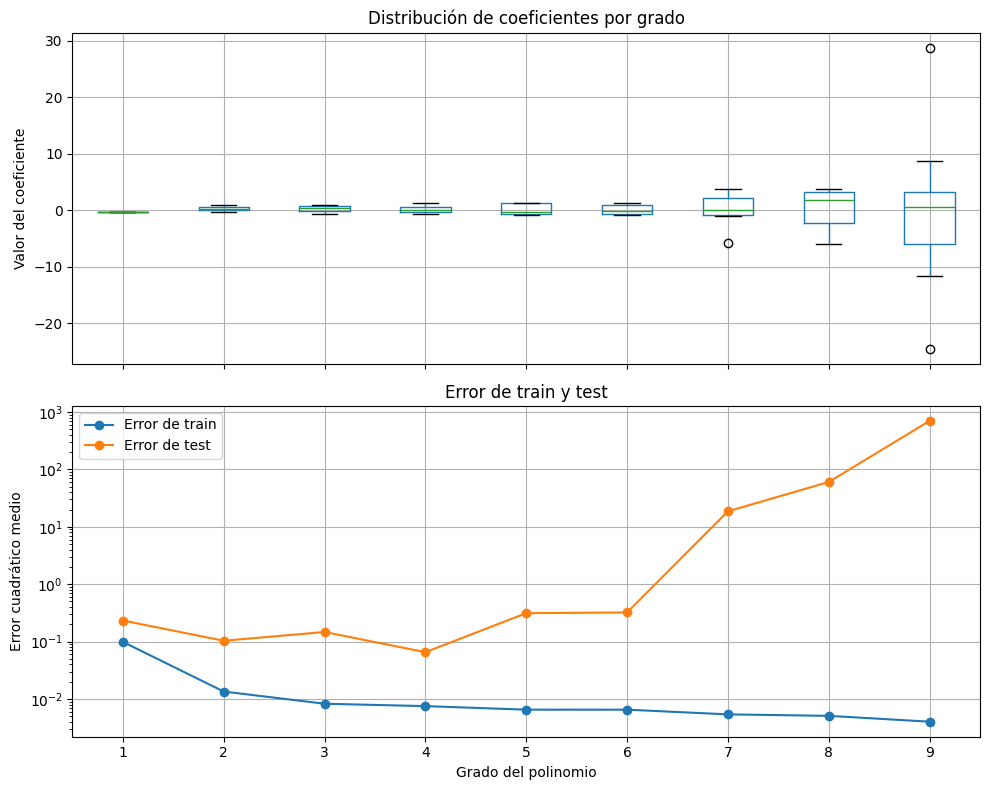

In [49]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Arriba: distribución de coeficientes
coefs_df.T.boxplot(ax=axs[0])
axs[0].set_ylabel("Valor del coeficiente")
axs[0].set_title("Distribución de coeficientes por grado")
axs[0].grid(True)

# Abajo: errores de train y test
axs[1].plot(degrees, train_errors, label="Error de train", marker='o')
axs[1].plot(degrees, test_errors, label="Error de test", marker='o')
axs[1].set_xlabel("Grado del polinomio")
axs[1].set_ylabel("Error cuadrático medio")
axs[1].set_title("Error de train y test")
axs[1].legend()
axs[1].grid(True)
axs[1].set_yscale('log')
plt.tight_layout()
plt.show()


In [58]:
def true_function(x, noise_std=0.3):
    noise = noise_std * np.random.randn(len(x))
    return np.sin(np.pi * x) + noise
n_samples = 30

# Data
X = np.linspace(-1, 1, n_samples)
y_true = true_function(X, noise_std=0)

# Parameters
alphas = np.logspace(-5, 1, 10)
degree = 20

# Store results
bias2_list, var_list = [], []
# Settings
np.random.seed(0)
n_trials = 30

for alpha in alphas:
    preds = []
    for _ in range(n_trials):
        y = true_function(X)

        model = make_pipeline(
            PolynomialFeatures(degree, include_bias=False),
            Ridge(alpha=alpha)
        )
        model.fit(X.reshape(-1, 1), y)
        preds.append(model.predict(X.reshape(-1, 1)))

    preds = np.array(preds)
    mean_preds = preds.mean(axis=0)

    bias2 = np.mean((mean_preds - y_true)**2)
    var = np.mean(np.var(preds, axis=0))

    bias2_list.append(bias2)
    var_list.append(var)

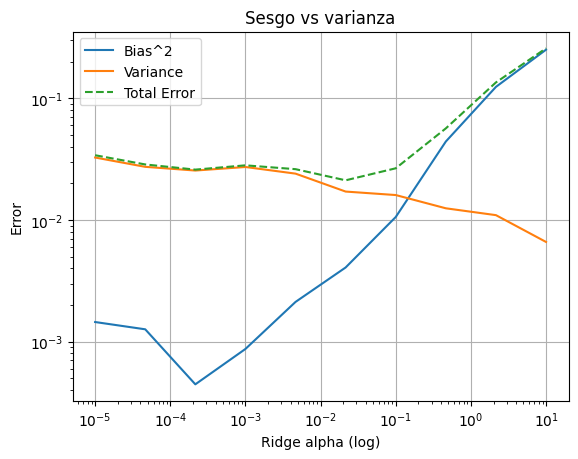

In [59]:
# Plot
plt.figure()
plt.plot(alphas, bias2_list, label='Bias^2')
plt.plot(alphas, var_list, label='Variance')
plt.plot(alphas, np.array(bias2_list) + np.array(var_list), label='Total Error', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Ridge alpha (log)')
plt.ylabel('Error')
plt.title('Sesgo vs varianza')
plt.legend()
plt.grid(True)
plt.show()

In [60]:
# Parameters
alphas = [0, 1e-5, 1e-2, 1]
degree = 20

models = []
y = true_function(X)
for alpha in alphas:
    model = make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        Ridge(alpha=alpha)
    )
    model.fit(X.reshape(-1, 1), y)
    models.append(model)


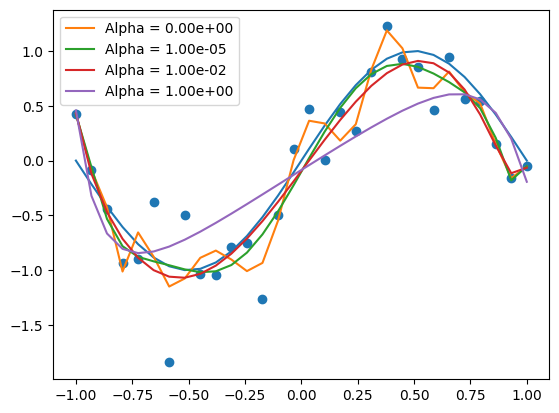

In [34]:
plt.figure()
plt.plot(X, y_true)
plt.scatter(X, y)
for alpha, model in zip(alphas, models):
  y_pred = model.predict(X.reshape(-1, 1))
  plt.plot(X, y_pred, label=f'Alpha = {alpha:.2e}')
plt.legend(loc='best')